# Curvas de Aprendizado — TREC 2007

Avaliação do desempenho dos quatro modelos (Naive Bayes, SVM, Random Forest e Regressão Logística) em função do tamanho do conjunto de treino, utilizando a métrica F1-score com validação cruzada de 5 folds.

Objetivos:
- Visualizar como cada modelo evolui conforme recebe mais dados de treinamento;
- Identificar possíveis problemas de **overfitting** ou **underfitting**;
- Determinar a fração mínima de dados necessária para cada modelo atingir desempenho próximo ao máximo;
- Comparar as curvas de validação dos quatro modelos em um único gráfico.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from pathlib import Path

# ── Caminhos ──────────────────────────────────────────────
BASE_DIR    = Path().resolve().parent.parent
MODELS_DIR  = BASE_DIR / 'models'
TREC_DIR    = MODELS_DIR / 'trec'
FIGURES_DIR = BASE_DIR / 'figures'
CONCL_FIG   = FIGURES_DIR / 'conclusions'
CONCL_FIG.mkdir(parents=True, exist_ok=True)

# ── Carregar dados ────────────────────────────────────────
with open(TREC_DIR / 'X_train_tfidf.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open(TREC_DIR / 'X_test_tfidf.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open(TREC_DIR / 'y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open(TREC_DIR / 'y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

# ── Paleta de cores ───────────────────────────────────────
NAVY   = '#1C2B4A'
TEAL   = '#0891B2'
BLUE   = '#2563EB'
GRAY   = '#64748B'
ORANGE = '#F59E0B'

MODEL_COLORS = {
    'Naive Bayes':         NAVY,
    'SVM':                 TEAL,
    'Random Forest':       BLUE,
    'Regressão Logística': GRAY,
}

# ── Definição dos modelos ─────────────────────────────────
MODELS = {
    'Naive Bayes':         MultinomialNB(),
    'SVM':                 LinearSVC(random_state=42, max_iter=2000, dual='auto'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
}

# ── Estilo global dos gráficos ────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titleweight': 'bold',
})

print(f'Projeto em       : {BASE_DIR}')
print(f'Figuras salvas em: {CONCL_FIG}')
print(f'X_train shape    : {X_train.shape}')
print(f'y_train shape    : {y_train.shape}')

/tmp/ipykernel_18018/690344518.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Projeto em       : /home/edson-luiz/Projetos/TCC
Figuras salvas em: /home/edson-luiz/Projetos/TCC/figures/conclusions
X_train shape    : (59019, 10000)
y_train shape    : (59019,)


In [2]:
# ── Gerar curvas de aprendizado para cada modelo ──────────
train_sizes_frac = np.linspace(0.1, 1.0, 10)

results = {}

for name, model in MODELS.items():
    print(f'Calculando curva de aprendizado: {name} ...', end=' ', flush=True)
    
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        train_sizes=train_sizes_frac,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        random_state=42,
    )
    
    results[name] = {
        'train_sizes': train_sizes_abs,
        'train_mean':  train_scores.mean(axis=1),
        'train_std':   train_scores.std(axis=1),
        'val_mean':    val_scores.mean(axis=1),
        'val_std':     val_scores.std(axis=1),
    }
    
    print(f'F1 validação final = {val_scores.mean(axis=1)[-1]:.4f}')

print('\nConcluído.')

Calculando curva de aprendizado: Naive Bayes ... 

F1 validação final = 0.9629
Calculando curva de aprendizado: SVM ... 

F1 validação final = 0.9945
Calculando curva de aprendizado: Random Forest ... 

F1 validação final = 0.9938
Calculando curva de aprendizado: Regressão Logística ... 

F1 validação final = 0.9921

Concluído.


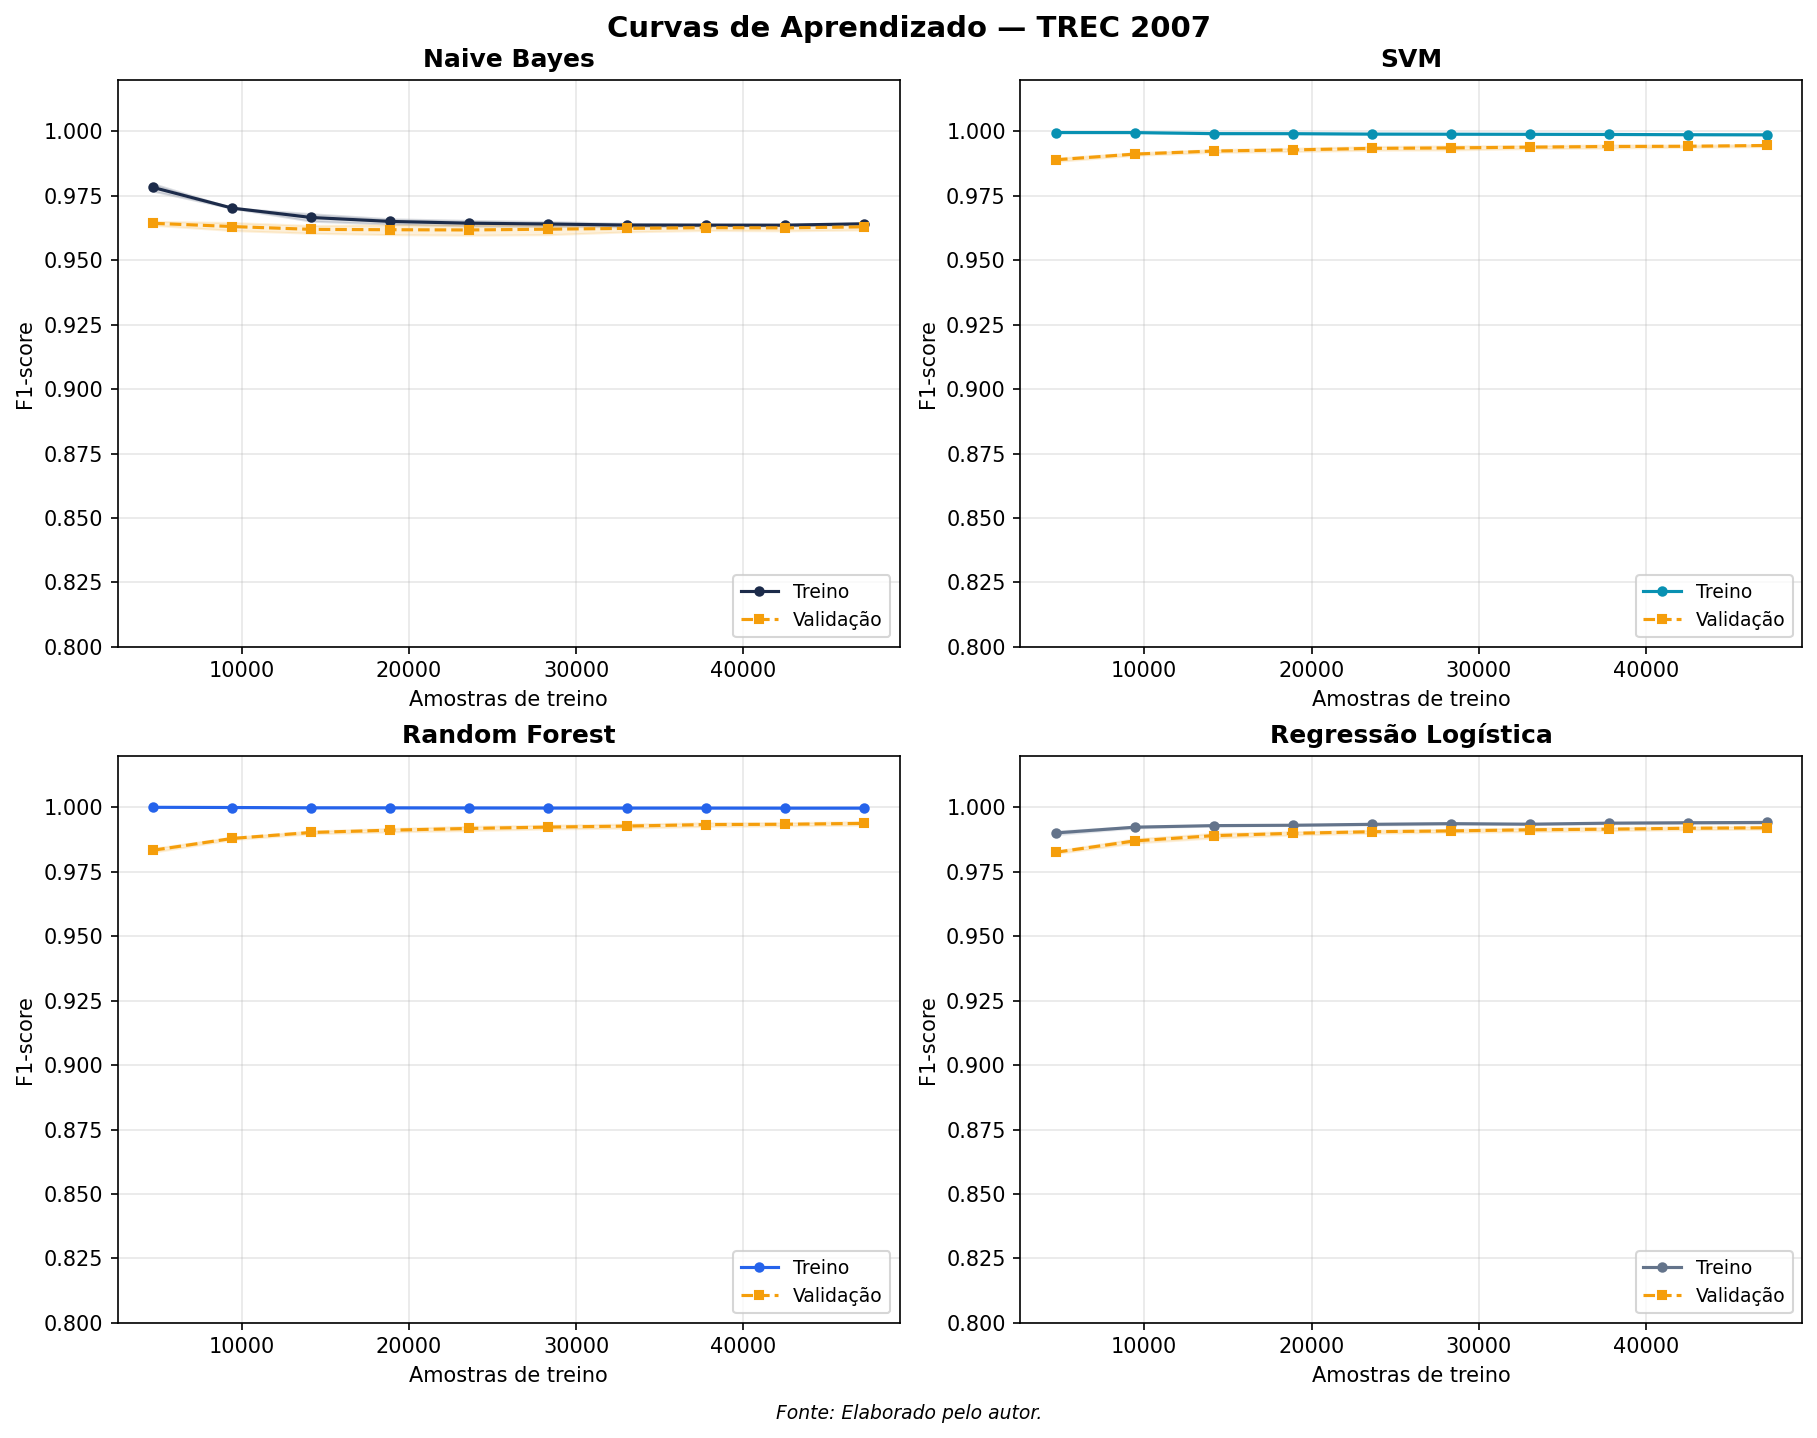

In [3]:
# ── Curvas de aprendizado individuais (2x2) ───────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
fig.suptitle('Curvas de Aprendizado — TREC 2007', fontsize=14, fontweight='bold', y=1.02)

for ax, (name, res) in zip(axes.flat, results.items()):
    color = MODEL_COLORS[name]
    sizes = res['train_sizes']
    
    # Treino
    ax.plot(sizes, res['train_mean'], 'o-', color=color, label='Treino', markersize=4)
    ax.fill_between(sizes,
                     res['train_mean'] - res['train_std'],
                     res['train_mean'] + res['train_std'],
                     alpha=0.15, color=color)
    
    # Validação
    ax.plot(sizes, res['val_mean'], 's--', color=ORANGE, label='Validação', markersize=4)
    ax.fill_between(sizes,
                     res['val_mean'] - res['val_std'],
                     res['val_mean'] + res['val_std'],
                     alpha=0.15, color=ORANGE)
    
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Amostras de treino')
    ax.set_ylabel('F1-score')
    ax.set_ylim(0.80, 1.02)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.text(0.5, -0.02, 'Fonte: Elaborado pelo autor.', ha='center', fontsize=9, style='italic')
plt.show()

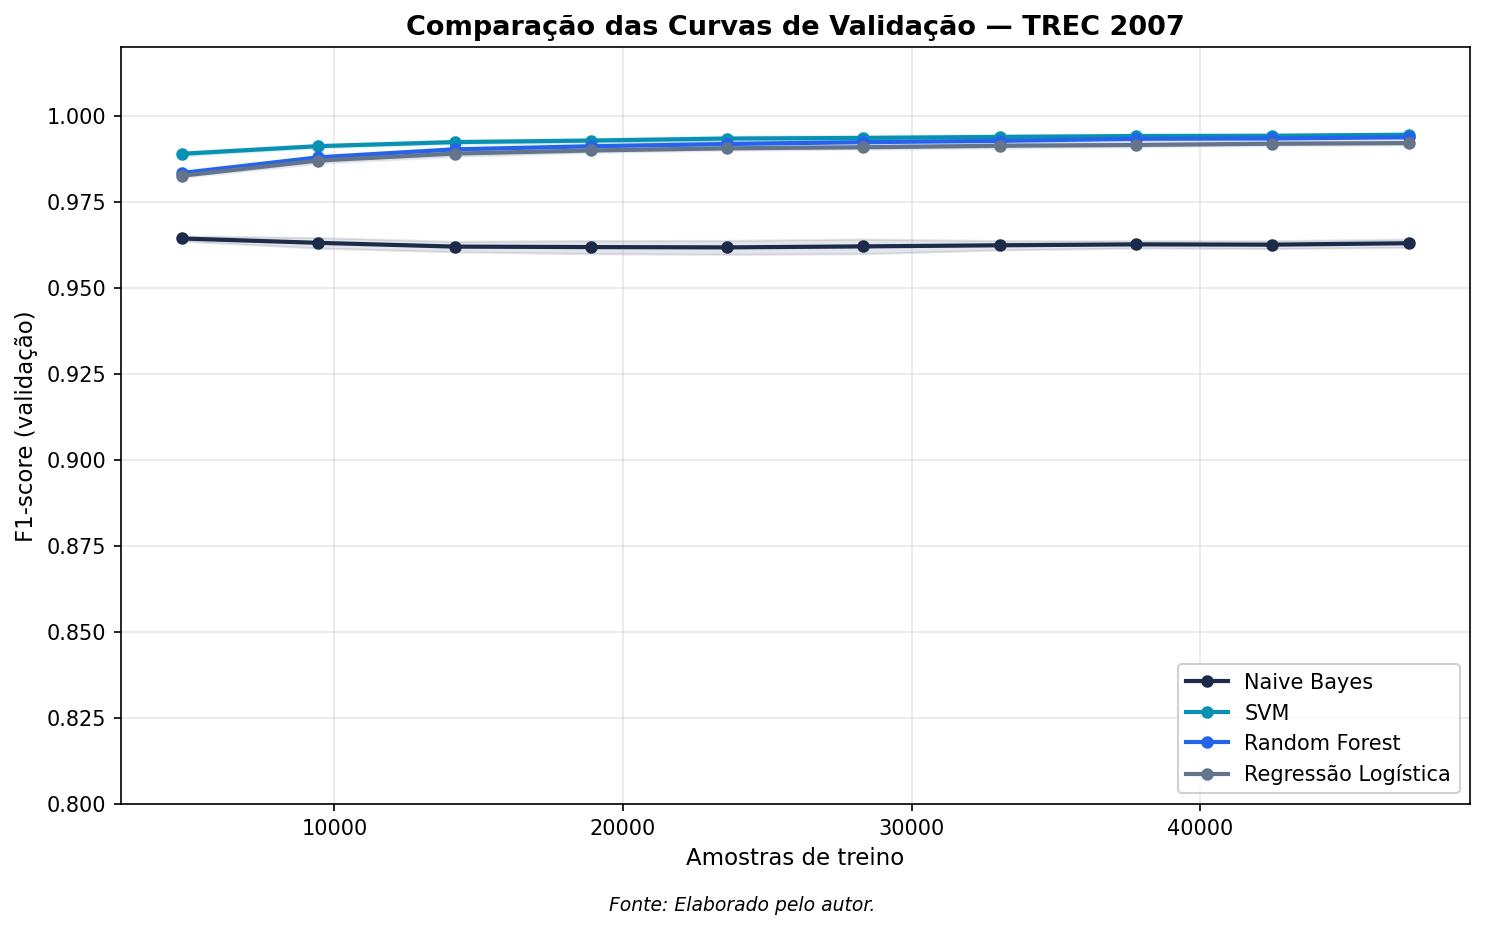

In [4]:
# ── Curvas de validação combinadas ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for name, res in results.items():
    color = MODEL_COLORS[name]
    sizes = res['train_sizes']
    
    ax.plot(sizes, res['val_mean'], 'o-', color=color, label=name, markersize=5, linewidth=2)
    ax.fill_between(sizes,
                     res['val_mean'] - res['val_std'],
                     res['val_mean'] + res['val_std'],
                     alpha=0.12, color=color)

ax.set_title('Comparação das Curvas de Validação — TREC 2007', fontsize=13, fontweight='bold')
ax.set_xlabel('Amostras de treino', fontsize=11)
ax.set_ylabel('F1-score (validação)', fontsize=11)
ax.set_ylim(0.80, 1.02)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

fig.text(0.5, -0.02, 'Fonte: Elaborado pelo autor.', ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

In [5]:
# ── Análise de convergência ────────────────────────────────
# Para cada modelo, determinar a menor fração de treino em que o F1 de
# validação atinge 99,5% (ou seja, fica a 0,5% do seu máximo).

THRESHOLD = 0.005  # 0,5%

convergence_rows = []

for name, res in results.items():
    val_mean  = res['val_mean']
    sizes     = res['train_sizes']
    max_f1    = val_mean.max()
    target_f1 = max_f1 * (1 - THRESHOLD)
    
    # Primeira posição em que atinge o limiar
    mask = val_mean >= target_f1
    if mask.any():
        idx = np.argmax(mask)
        conv_size = sizes[idx]
        conv_frac = conv_size / sizes[-1]
        conv_f1   = val_mean[idx]
    else:
        conv_size = sizes[-1]
        conv_frac = 1.0
        conv_f1   = val_mean[-1]
    
    convergence_rows.append({
        'Modelo':                    name,
        'F1 máximo (validação)':     f'{max_f1:.4f}',
        'Limiar (99,5% do máx.)':    f'{target_f1:.4f}',
        'Amostras p/ convergência':  int(conv_size),
        'Fração do treino':          f'{conv_frac:.1%}',
        'F1 na convergência':        f'{conv_f1:.4f}',
    })

df_conv = pd.DataFrame(convergence_rows)
print('Análise de Convergência — em que ponto cada modelo atinge 99,5% do seu F1 máximo?\n')
df_conv

Análise de Convergência — em que ponto cada modelo atinge 99,5% do seu F1 máximo?



,Modelo,F1 máximo (validação),"Limiar (99,5% do máx.)",Amostras p/ convergência,Fração do treino,F1 na convergência
0,Naive Bayes,0.9643,0.9595,4721,10.0%,0.9643
1,SVM,0.9945,0.9895,9443,20.0%,0.9912
2,Random Forest,0.9938,0.9888,14164,30.0%,0.9902
3,Regressão Logística,0.9921,0.9871,14164,30.0%,0.9890


## Interpretação

**Observações gerais:**

1. **Overfitting vs. Underfitting:** Modelos cujas curvas de treino e validação convergem rapidamente para valores próximos indicam boa generalização. Quando há uma grande lacuna persistente entre treino e validação, há indício de overfitting.

2. **Naive Bayes** tende a convergir com poucos dados, refletindo sua natureza paramétrica simples e suas suposições de independência condicional. Entretanto, seu desempenho máximo pode ser inferior ao dos demais modelos.

3. **SVM (LinearSVC)** e **Regressão Logística** costumam apresentar curvas de validação crescentes e estáveis, beneficiando-se de mais dados de forma consistente, com gap moderado entre treino e validação.

4. **Random Forest**, por ser um ensemble de árvores de decisão, pode apresentar F1 de treino próximo a 1.0 (overfitting nas árvores individuais), mas sua curva de validação revela o desempenho real de generalização.

5. **Convergência:** A tabela acima mostra a fração mínima de dados necessária para cada modelo atingir 99,5% do seu F1 máximo de validação. Modelos que convergem mais cedo são mais eficientes em termos de dados — uma informação relevante para cenários com dados rotulados escassos.

**Implicações práticas:**
- Se o custo de rotulagem for alto, modelos que convergem rapidamente (com menos dados) são preferíveis.
- A comparação das curvas de validação no gráfico combinado permite identificar qual modelo domina em diferentes regimes de dados.

In [6]:
# ── Salvar figuras ─────────────────────────────────────────

# Figura 1 — Curvas individuais (2x2)
fig1, axes1 = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
fig1.suptitle('Curvas de Aprendizado — TREC 2007', fontsize=14, fontweight='bold', y=1.02)

for ax, (name, res) in zip(axes1.flat, results.items()):
    color = MODEL_COLORS[name]
    sizes = res['train_sizes']
    
    ax.plot(sizes, res['train_mean'], 'o-', color=color, label='Treino', markersize=4)
    ax.fill_between(sizes,
                     res['train_mean'] - res['train_std'],
                     res['train_mean'] + res['train_std'],
                     alpha=0.15, color=color)
    
    ax.plot(sizes, res['val_mean'], 's--', color=ORANGE, label='Validação', markersize=4)
    ax.fill_between(sizes,
                     res['val_mean'] - res['val_std'],
                     res['val_mean'] + res['val_std'],
                     alpha=0.15, color=ORANGE)
    
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Amostras de treino')
    ax.set_ylabel('F1-score')
    ax.set_ylim(0.80, 1.02)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

fig1.text(0.5, -0.02, 'Fonte: Elaborado pelo autor.', ha='center', fontsize=9, style='italic')
fig1.savefig(CONCL_FIG / 'learning_curves_individual.png', bbox_inches='tight', facecolor='white')
print(f'Salvo: {CONCL_FIG / "learning_curves_individual.png"}')

# Figura 2 — Curvas de validação combinadas
fig2, ax2 = plt.subplots(figsize=(10, 6))

for name, res in results.items():
    color = MODEL_COLORS[name]
    sizes = res['train_sizes']
    
    ax2.plot(sizes, res['val_mean'], 'o-', color=color, label=name, markersize=5, linewidth=2)
    ax2.fill_between(sizes,
                      res['val_mean'] - res['val_std'],
                      res['val_mean'] + res['val_std'],
                      alpha=0.12, color=color)

ax2.set_title('Comparação das Curvas de Validação — TREC 2007', fontsize=13, fontweight='bold')
ax2.set_xlabel('Amostras de treino', fontsize=11)
ax2.set_ylabel('F1-score (validação)', fontsize=11)
ax2.set_ylim(0.80, 1.02)
ax2.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax2.grid(True, alpha=0.3)

fig2.text(0.5, -0.02, 'Fonte: Elaborado pelo autor.', ha='center', fontsize=9, style='italic')
fig2.savefig(CONCL_FIG / 'learning_curves_combined.png', bbox_inches='tight', facecolor='white')
print(f'Salvo: {CONCL_FIG / "learning_curves_combined.png"}')

plt.close('all')
print('\nFiguras salvas com sucesso.')

Salvo: /home/edson-luiz/Projetos/TCC/figures/conclusions/learning_curves_individual.png


Salvo: /home/edson-luiz/Projetos/TCC/figures/conclusions/learning_curves_combined.png

Figuras salvas com sucesso.
